#  Image Classification with CNN — Vegetable Dataset
**Dataset:** [Vegetable Image Dataset (Kaggle)](https://www.kaggle.com/datasets/misrakahmed/vegetable-image-dataset)  
**Classes:** 15 vegetables | **Total Images:** 21,000  
**Framework:** Keras (TensorFlow backend)  
**Runtime:** Enable GPU in Colab → Runtime > Change runtime type > GPU

## Step 0 — Setup: Install Kaggle & Download Dataset

In [5]:
import os
from google.colab import drive
drive.mount('/content/drive')

import os, zipfile

#  this path to where your zip file is in Google Drive
ZIP_PATH   = '/content/archive (7).zip'
EXTRACT_TO = '/content/vegetables'

# Create extraction directory if it doesn't exist
os.makedirs(EXTRACT_TO, exist_ok=True)

# Unzip the dataset if it hasn't been unzipped yet
if not os.path.exists(os.path.join(EXTRACT_TO, 'Vegetable Images', 'train')):
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_TO)
    print(f'Dataset unzipped to {EXTRACT_TO}')
else:
    print(f'Dataset already unzipped in {EXTRACT_TO}')

# Confirm folder structure
for root, dirs, files in os.walk(EXTRACT_TO):
    level = root.replace(EXTRACT_TO, '').count(os.sep)
    if level < 2:   # only show top 2 levels
        indent = '  ' * level
        print(f'{indent}{os.path.basename(root)}/')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset unzipped to /content/vegetables
vegetables/
  Vegetable Images/


In [6]:
import zipfile

# Assuming ZIP_PATH is defined from the previous cell
print(f"Checking integrity of {ZIP_PATH}...")
try:
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        bad_file = zip_ref.testzip()
        if bad_file is None:
            print("The zip file appears to be valid (no errors found during CRC check).")
        else:
            print(f"The zip file is corrupted. The first bad file found is: {bad_file}")
except zipfile.BadZipFile:
    print("The file is not a valid zip archive or is severely corrupted.")
except FileNotFoundError:
    print(f"Error: The file {ZIP_PATH} was not found.")


Checking integrity of /content/archive (7).zip...
The zip file appears to be valid (no errors found during CRC check).


## Step 1 — Import Libraries

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, time
from PIL import Image

from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Step 2 — Dataset Paths & Configuration

In [8]:
BASE_DIR   = '/content/vegetables/Vegetable Images'
TRAIN_DIR  = os.path.join(BASE_DIR, 'train')
VAL_DIR    = os.path.join(BASE_DIR, 'validation')
TEST_DIR   = os.path.join(BASE_DIR, 'test')

IMG_SIZE   = (64, 64)   # resize all images to 64x64
BATCH_SIZE = 32
EPOCHS     = 20
NUM_CLASSES = 15

CLASSES = sorted(os.listdir(TRAIN_DIR))
print('Classes:', CLASSES)
print('Number of classes:', len(CLASSES))

Classes: ['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 'Papaya', 'Potato', 'Pumpkin', 'Radish', 'Tomato']
Number of classes: 15


## Step 3 — Data Understanding & Visualization

In [9]:
# Count images per class per split
def count_images(directory):
    counts = {}
    for cls in sorted(os.listdir(directory)):
        cls_path = os.path.join(directory, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len(os.listdir(cls_path))
    return counts

train_counts = count_images(TRAIN_DIR)
val_counts   = count_images(VAL_DIR)
test_counts  = count_images(TEST_DIR)

# Print table
print(f"{'Class':<20} {'Train':>8} {'Val':>8} {'Test':>8} {'Total':>8}")
print('-' * 52)
for c in CLASSES:
    tr, va, te = train_counts[c], val_counts[c], test_counts[c]
    print(f"{c:<20} {tr:>8} {va:>8} {te:>8} {tr+va+te:>8}")
print('-' * 52)
total = sum(train_counts.values()) + sum(val_counts.values()) + sum(test_counts.values())
print(f"{'TOTAL':<20} {sum(train_counts.values()):>8} {sum(val_counts.values()):>8} {sum(test_counts.values()):>8} {total:>8}")

Class                   Train      Val     Test    Total
----------------------------------------------------
Bean                     1000      200      200     1400
Bitter_Gourd             1000      200      200     1400
Bottle_Gourd             1000      200      200     1400
Brinjal                  1000      200      200     1400
Broccoli                 1000      200      200     1400
Cabbage                  1000      200      200     1400
Capsicum                 1000      200      200     1400
Carrot                   1000      200      200     1400
Cauliflower              1000      200      200     1400
Cucumber                 1000      200      200     1400
Papaya                   1000      200      200     1400
Potato                   1000      200      200     1400
Pumpkin                  1000      200      200     1400
Radish                   1000      200      200     1400
Tomato                   1000      200      200     1400
-----------------------------------

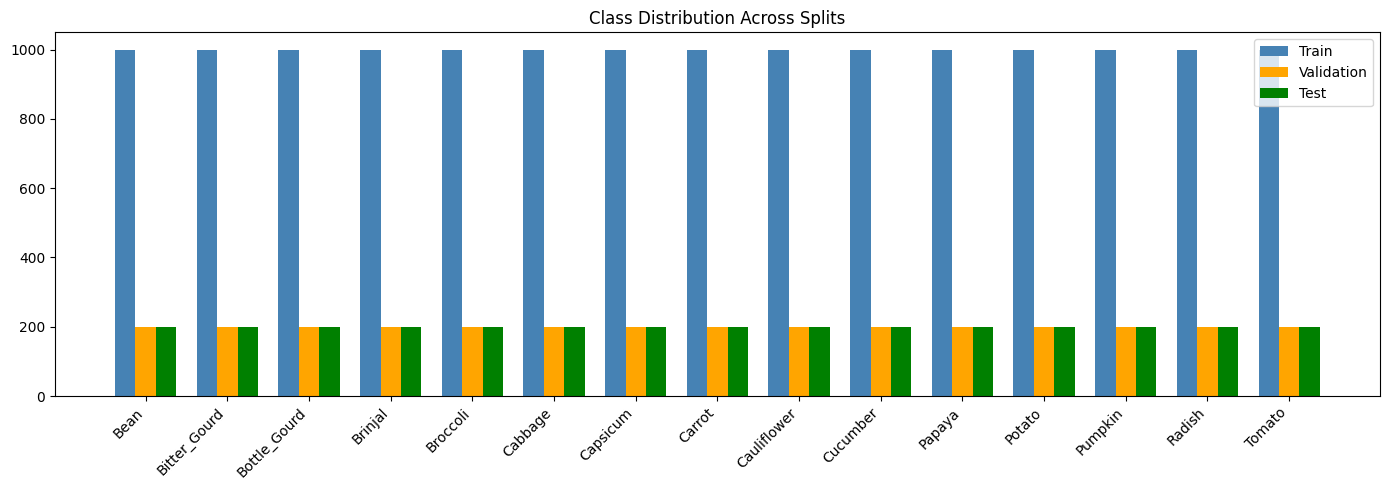

In [10]:
# Bar chart — class distribution
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(CLASSES))
w = 0.25
ax.bar(x - w, [train_counts[c] for c in CLASSES], w, label='Train', color='steelblue')
ax.bar(x,     [val_counts[c]   for c in CLASSES], w, label='Validation', color='orange')
ax.bar(x + w, [test_counts[c]  for c in CLASSES], w, label='Test', color='green')
ax.set_xticks(x)
ax.set_xticklabels(CLASSES, rotation=45, ha='right')
ax.set_title('Class Distribution Across Splits')
ax.legend()
plt.tight_layout()
plt.show()

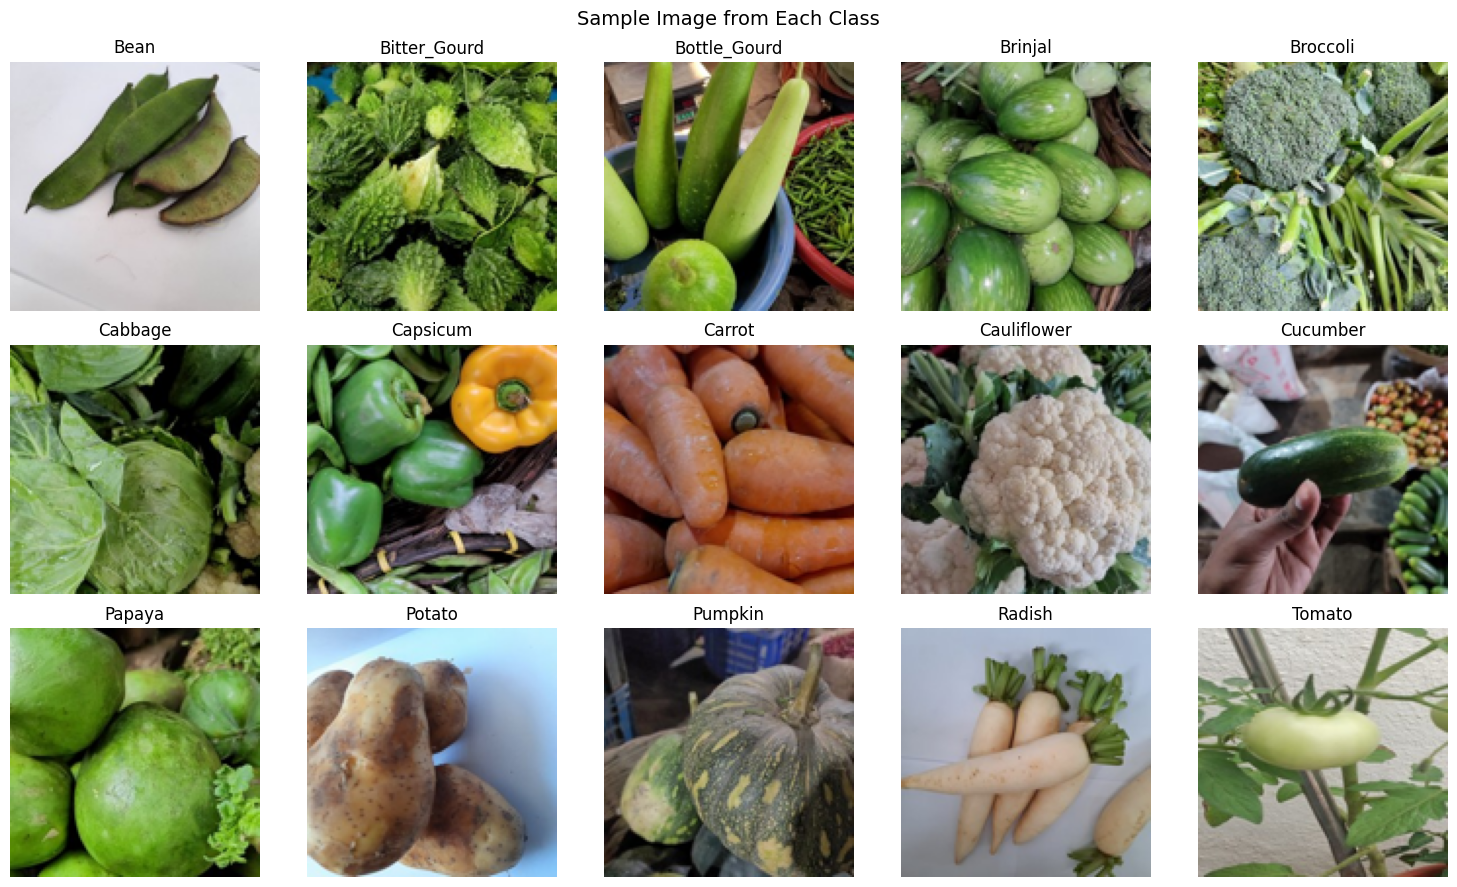

In [11]:
# Show sample images from each class
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()
for i, cls in enumerate(CLASSES):
    cls_path = os.path.join(TRAIN_DIR, cls)
    img_file = os.listdir(cls_path)[0]
    img = Image.open(os.path.join(cls_path, img_file)).resize((128, 128))
    axes[i].imshow(img)
    axes[i].set_title(cls)
    axes[i].axis('off')
plt.suptitle('Sample Image from Each Class', fontsize=14)
plt.tight_layout()
plt.show()

## Step 4 — Data Generators (Preprocessing + Augmentation)

In [12]:
# Training generator WITH augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

# Validation/Test generators — only rescale
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical')

val_gen = val_test_datagen.flow_from_directory(
    VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

Found 15000 images belonging to 15 classes.
Found 3000 images belonging to 15 classes.
Found 3000 images belonging to 15 classes.


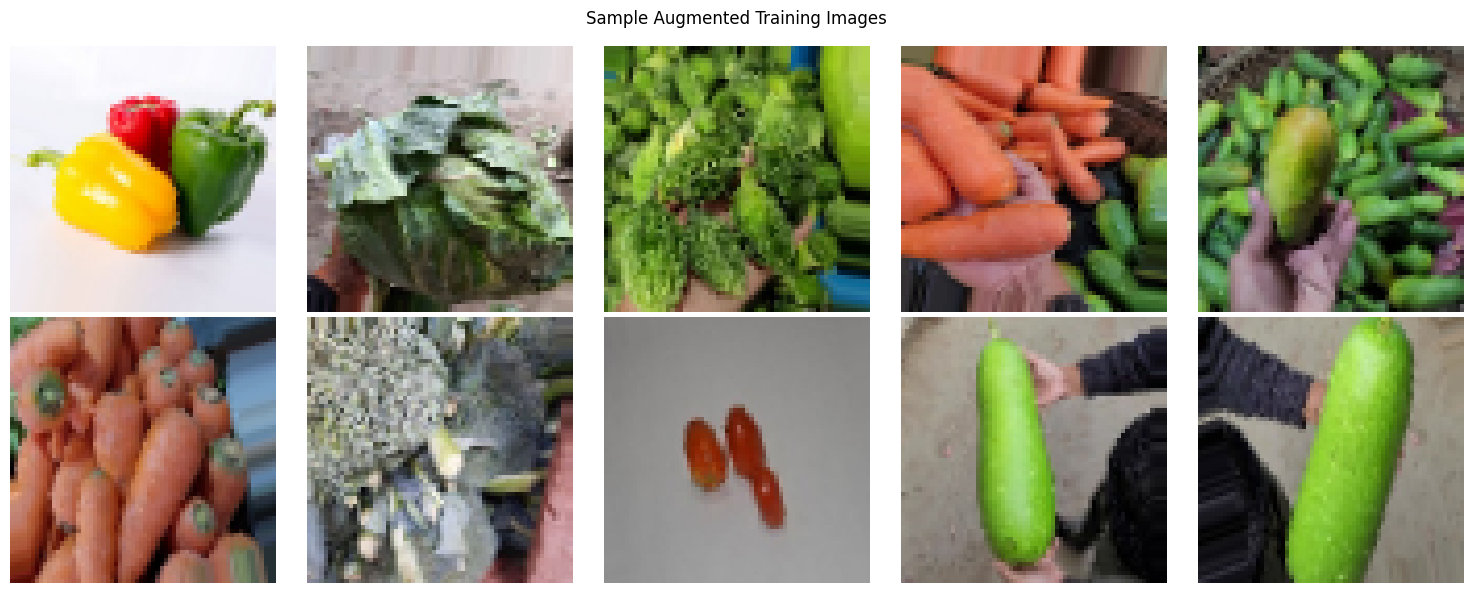

In [13]:
# Visualize augmented images
sample_imgs, _ = next(train_gen)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_imgs[i])
    ax.axis('off')
plt.suptitle('Sample Augmented Training Images')
plt.tight_layout()
plt.show()

---
# PART A — CNN From Scratch
## Step 5 — Baseline CNN Model (3 Conv + 3 FC layers)

In [14]:
def build_baseline():
    model = keras.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(64,64,3)),
        layers.MaxPooling2D(2,2),
        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        # Flatten
        layers.Flatten(),
        # FC layers
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(64,  activation='relu'),
        # Output
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='Baseline_CNN')
    return model

baseline_model = build_baseline()
baseline_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,232,783 (8.52 MB)

 Trainable params: 2,232,783 (8.52 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Train Baseline Model
start = time.time()
history_baseline = baseline_model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    verbose=1
)
baseline_time = time.time() - start
print(f'\nBaseline training time: {baseline_time/60:.1f} minutes')

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 49s 91ms/step - accuracy: 0.4261 - loss: 1.6320 - val_accuracy: 0.6247 - val_loss: 1.1901
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 37s 79ms/step - accuracy: 0.7126 - loss: 0.8608 - val_accuracy: 0.7743 - val_loss: 0.6920
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 38s 81ms/step - accuracy: 0.8329 - loss: 0.5095 - val_accuracy: 0.8580 - val_loss: 0.4327
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 37s 80ms/step - accuracy: 0.8850 - loss: 0.3616 - val_accuracy: 0.8840 - val_loss: 0.3476
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 36s 76ms/step - accuracy: 0.9084 - loss: 0.2849 - val_accuracy: 0.9340 - val_loss: 0.2130
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 38s 80ms/step - accuracy: 0.9243 - loss: 0.2374 - val_accuracy: 0.9303 - val_loss: 0.2519
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 36s 77ms/step - accuracy: 0.9397 - loss: 0.1894 - val_accuracy: 0.8590 - val_loss: 0.5021
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 38s 81ms/step - accuracy: 0.9453 - loss: 0.1720 - 

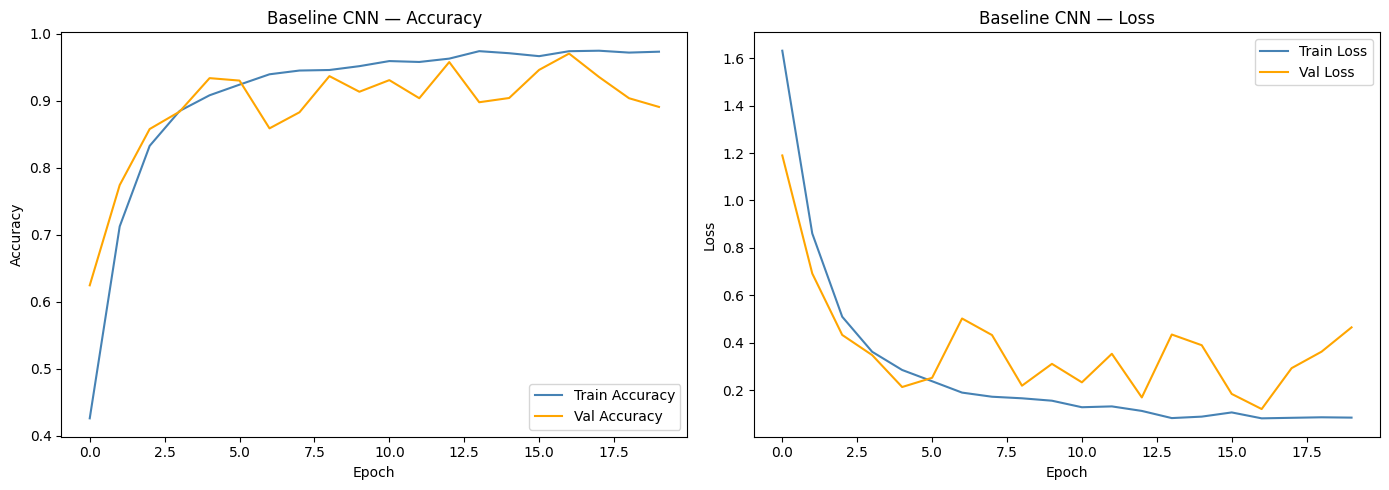

In [16]:
# Plot training curves — helper function
def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history.history['accuracy'],     label='Train Accuracy',   color='steelblue')
    ax1.plot(history.history['val_accuracy'], label='Val Accuracy',     color='orange')
    ax1.set_title(f'{title} — Accuracy')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
    ax1.legend()

    ax2.plot(history.history['loss'],     label='Train Loss', color='steelblue')
    ax2.plot(history.history['val_loss'], label='Val Loss',   color='orange')
    ax2.set_title(f'{title} — Loss')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend()
    plt.tight_layout()
    plt.show()

plot_history(history_baseline, 'Baseline CNN')


Baseline CNN — Test Loss: 0.4507 | Test Accuracy: 88.87%

Classification Report:
              precision    recall  f1-score   support

        Bean       0.91      0.94      0.92       200
Bitter_Gourd       0.91      0.91      0.91       200
Bottle_Gourd       0.99      0.99      0.99       200
     Brinjal       0.99      0.96      0.97       200
    Broccoli       0.86      0.70      0.77       200
     Cabbage       0.68      0.90      0.78       200
    Capsicum       1.00      0.97      0.99       200
      Carrot       1.00      1.00      1.00       200
 Cauliflower       0.66      0.97      0.79       200
    Cucumber       0.99      0.90      0.94       200
      Papaya       0.98      0.96      0.97       200
      Potato       0.99      0.96      0.97       200
     Pumpkin       0.89      0.62      0.73       200
      Radish       1.00      0.56      0.72       200
      Tomato       0.76      0.97      0.85       200

    accuracy                           0.89      300

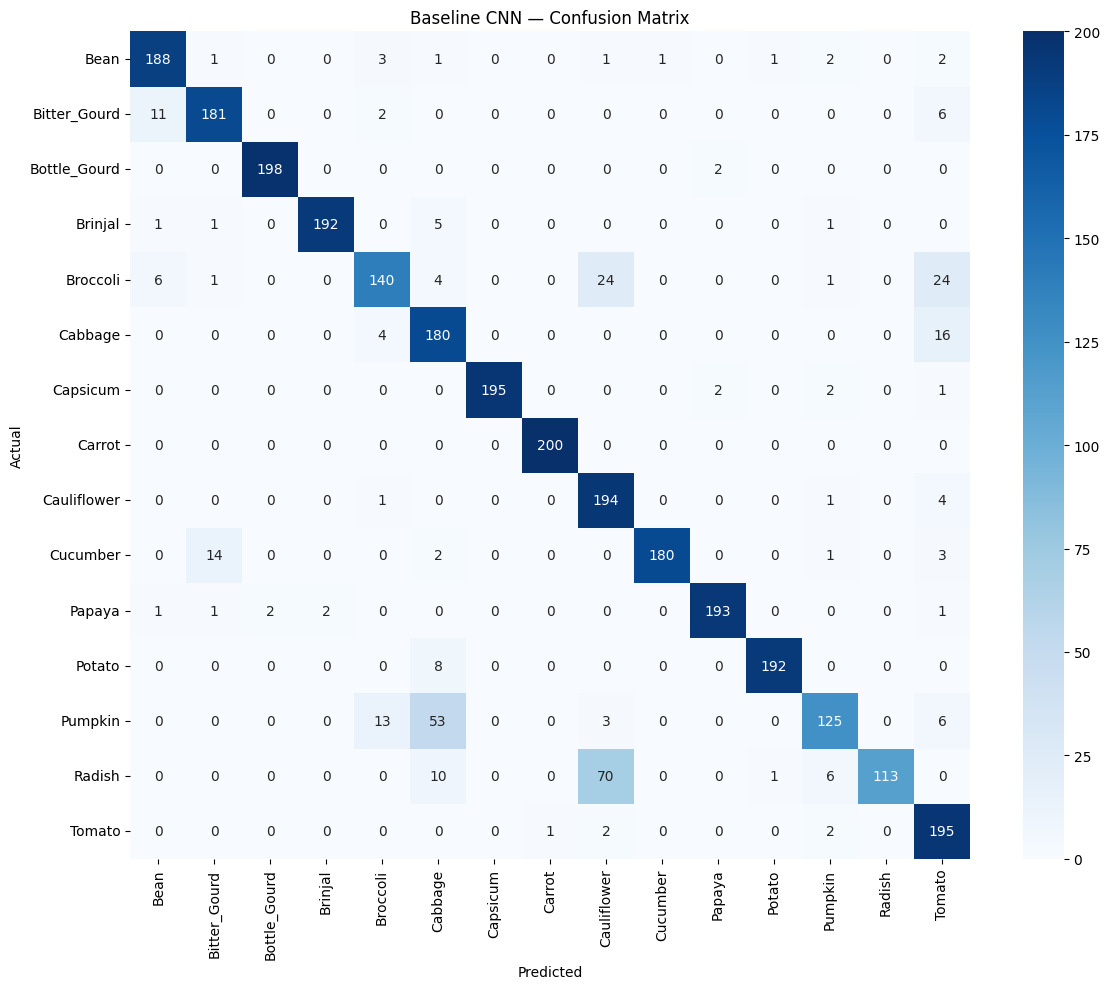

In [17]:
# Evaluate Baseline — helper function
def evaluate_model(model, generator, name):
    loss, acc = model.evaluate(generator, verbose=0)
    print(f'\n{name} — Test Loss: {loss:.4f} | Test Accuracy: {acc*100:.2f}%')

    y_pred = np.argmax(model.predict(generator, verbose=0), axis=1)
    y_true = generator.classes

    print('\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=CLASSES))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(f'{name} — Confusion Matrix')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()
    return acc

baseline_acc = evaluate_model(baseline_model, test_gen, 'Baseline CNN')

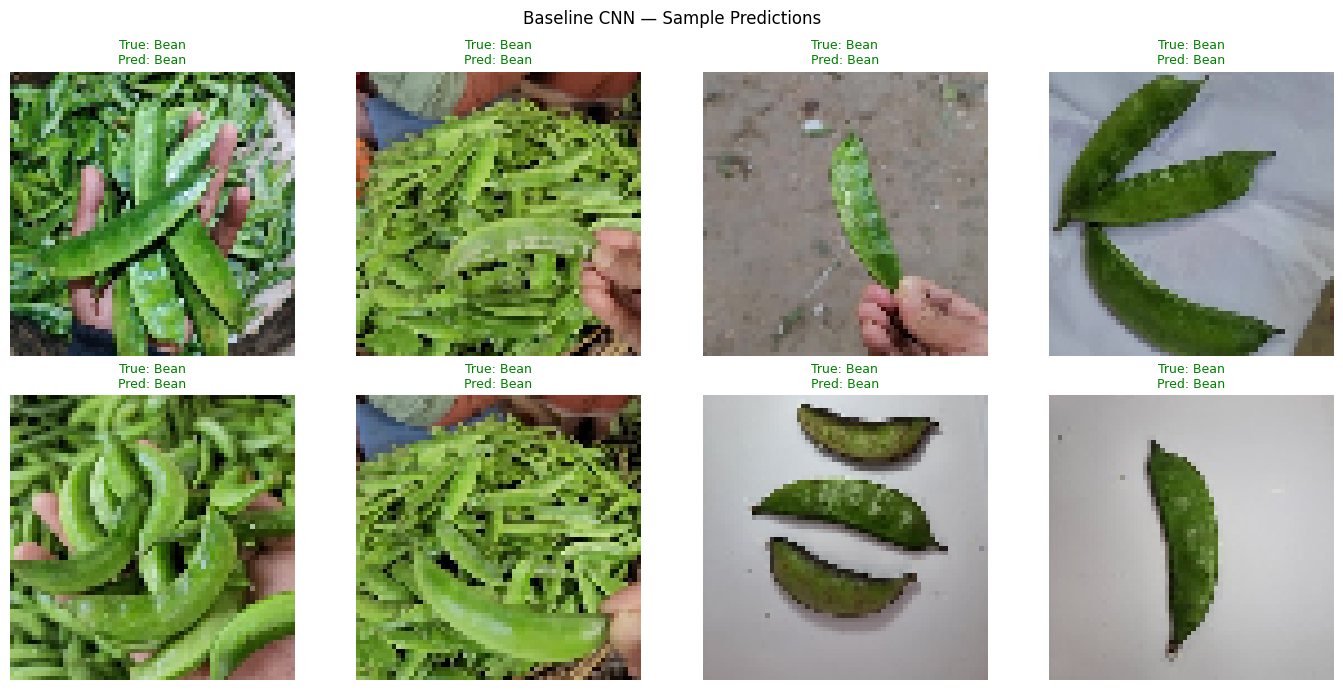

In [18]:
# Inference on sample images
test_gen.reset()
sample_imgs, sample_labels = next(test_gen)
preds = baseline_model.predict(sample_imgs[:8], verbose=0)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(sample_imgs[i])
    true_cls  = CLASSES[np.argmax(sample_labels[i])]
    pred_cls  = CLASSES[np.argmax(preds[i])]
    color = 'green' if true_cls == pred_cls else 'red'
    ax.set_title(f'True: {true_cls}\nPred: {pred_cls}', color=color, fontsize=9)
    ax.axis('off')
plt.suptitle('Baseline CNN — Sample Predictions')
plt.tight_layout()
plt.show()

## Step 6 — Deeper CNN with Regularization (Double the layers)

In [19]:
def build_deeper():
    model = keras.Sequential([
        # Block 1
        layers.Conv2D(32,  (3,3), activation='relu', padding='same', input_shape=(64,64,3)),
        layers.Conv2D(32,  (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),
        # Block 2
        layers.Conv2D(64,  (3,3), activation='relu', padding='same'),
        layers.Conv2D(64,  (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),
        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),
        # Flatten
        layers.Flatten(),
        # FC layers
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(128, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='Deeper_CNN')
    return model

deeper_model = build_deeper()
deeper_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
deeper_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,651,951 (17.75 MB)

 Trainable params: 4,649,967 (17.74 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [20]:
# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

start = time.time()
history_deeper = deeper_model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)
deeper_time = time.time() - start
print(f'\nDeeper model training time: {deeper_time/60:.1f} minutes')

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 65s 111ms/step - accuracy: 0.4419 - loss: 1.7075 - val_accuracy: 0.1583 - val_loss: 5.1589 - learning_rate: 0.0010
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 84ms/step - accuracy: 0.6750 - loss: 0.9651 - val_accuracy: 0.7223 - val_loss: 0.8775 - learning_rate: 0.0010
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 42s 89ms/step - accuracy: 0.7737 - loss: 0.7018 - val_accuracy: 0.5727 - val_loss: 1.8488 - learning_rate: 0.0010
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 39s 83ms/step - accuracy: 0.8251 - loss: 0.5421 - val_accuracy: 0.7387 - val_loss: 0.8011 - learning_rate: 0.0010
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 86ms/step - accuracy: 0.8585 - loss: 0.4419 - val_accuracy: 0.6460 - val_loss: 1.4621 - learning_rate: 0.0010
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 86ms/step - accuracy: 0.8861 - loss: 0.3600 - val_accuracy: 0.7660 - val_loss: 0.8635 - learning_rate: 0.0010
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 86ms/step - accuracy: 0.8891 - 

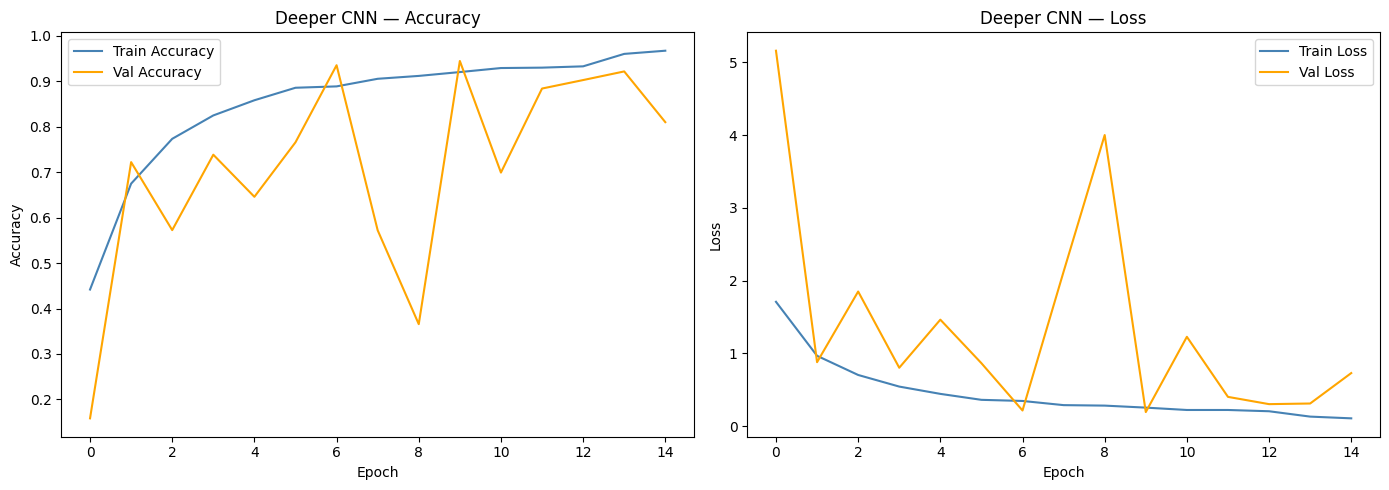


Deeper CNN — Test Loss: 0.1972 | Test Accuracy: 94.00%

Classification Report:
              precision    recall  f1-score   support

        Bean       0.96      0.96      0.96       200
Bitter_Gourd       0.88      0.93      0.90       200
Bottle_Gourd       1.00      0.90      0.94       200
     Brinjal       0.95      0.96      0.95       200
    Broccoli       0.79      0.98      0.88       200
     Cabbage       0.87      0.92      0.89       200
    Capsicum       0.99      0.99      0.99       200
      Carrot       0.97      1.00      0.99       200
 Cauliflower       0.89      0.93      0.91       200
    Cucumber       0.93      0.86      0.90       200
      Papaya       0.98      0.93      0.95       200
      Potato       1.00      1.00      1.00       200
     Pumpkin       0.99      0.90      0.94       200
      Radish       1.00      0.92      0.96       200
      Tomato       0.97      0.93      0.95       200

    accuracy                           0.94      3000


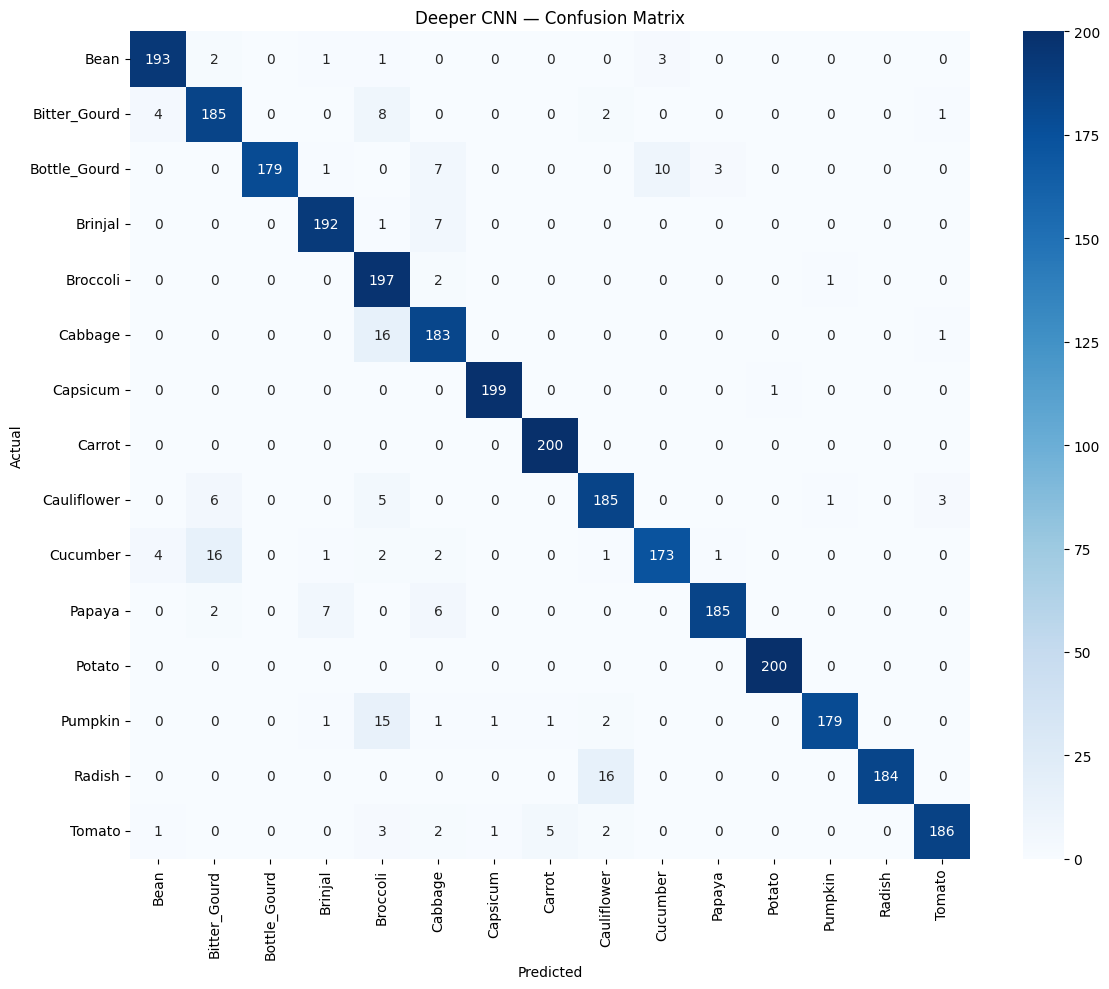

In [21]:
plot_history(history_deeper, 'Deeper CNN')
deeper_acc = evaluate_model(deeper_model, test_gen, 'Deeper CNN')

## Step 7 — Comparative Analysis & Experimentation

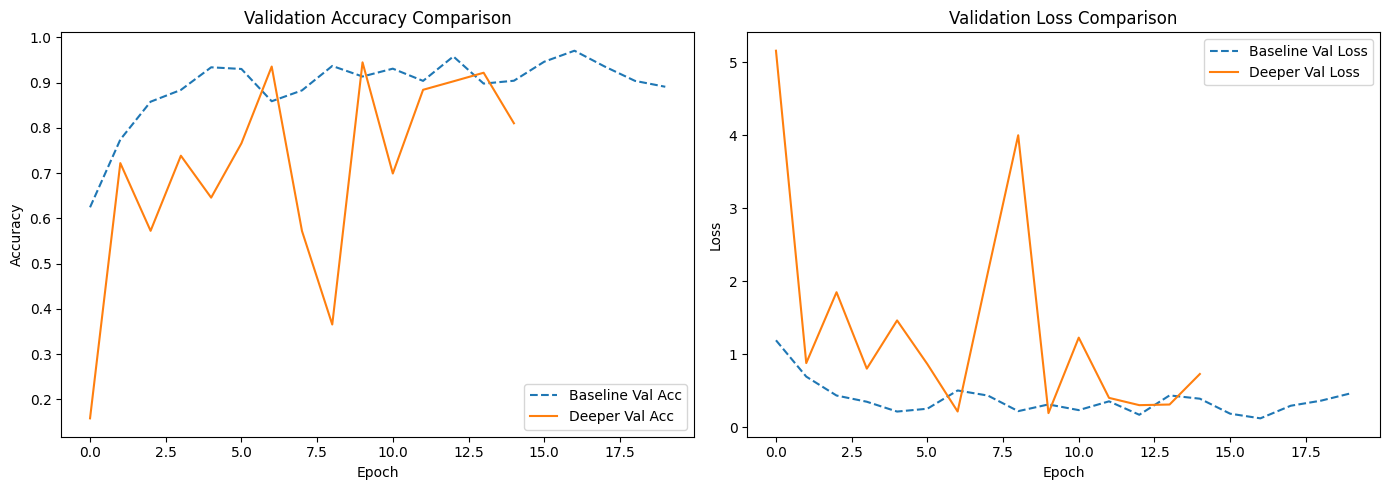


Baseline Accuracy : 88.87%
Deeper   Accuracy : 94.00%
Baseline Training Time : 12.8 min
Deeper   Training Time : 10.4 min


In [23]:
# Baseline vs Deeper — accuracy and loss on same plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_baseline.history['val_accuracy'], label='Baseline Val Acc', linestyle='--')
axes[0].plot(history_deeper.history['val_accuracy'],   label='Deeper Val Acc')
axes[0].set_title('Validation Accuracy Comparison')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend()

axes[1].plot(history_baseline.history['val_loss'], label='Baseline Val Loss', linestyle='--')
axes[1].plot(history_deeper.history['val_loss'],   label='Deeper Val Loss')
axes[1].set_title('Validation Loss Comparison')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\nBaseline Accuracy : {baseline_acc*100:.2f}%')
print(f'Deeper   Accuracy : {deeper_acc*100:.2f}%')
print(f'Baseline Training Time : {baseline_time/60:.1f} min')
print(f'Deeper   Training Time : {deeper_time/60:.1f} min')

In [24]:
# Optimizer Analysis: SGD vs Adam on Deeper Model
def train_with_optimizer(opt, opt_name):
    m = build_deeper()
    m.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    h = m.fit(train_gen, epochs=EPOCHS, validation_data=val_gen,
              callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
              verbose=0)
    val_acc = max(h.history['val_accuracy'])
    print(f'{opt_name} — Best Val Accuracy: {val_acc*100:.2f}%')
    return h

print('Training with SGD...')
history_sgd  = train_with_optimizer(keras.optimizers.SGD(learning_rate=0.01, momentum=0.9), 'SGD')

print('Training with Adam...')
history_adam = train_with_optimizer(keras.optimizers.Adam(learning_rate=0.001), 'Adam')

Training with SGD...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


SGD — Best Val Accuracy: 95.97%
Training with Adam...
Adam — Best Val Accuracy: 79.83%


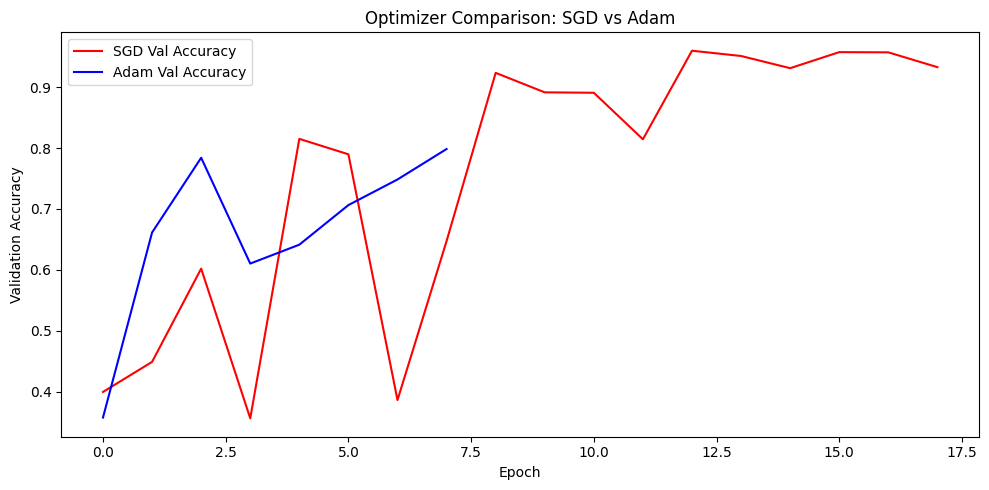

In [25]:
# SGD vs Adam comparison plot
plt.figure(figsize=(10, 5))
plt.plot(history_sgd.history['val_accuracy'],  label='SGD Val Accuracy',  color='red')
plt.plot(history_adam.history['val_accuracy'], label='Adam Val Accuracy', color='blue')
plt.title('Optimizer Comparison: SGD vs Adam')
plt.xlabel('Epoch'); plt.ylabel('Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 50s 93ms/step - accuracy: 0.6328 - loss: 1.1855 - val_accuracy: 0.5473 - val_loss: 1.9744
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 39s 82ms/step - accuracy: 0.8455 - loss: 0.4917 - val_accuracy: 0.6947 - val_loss: 1.1774
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 38s 82ms/step - accuracy: 0.8936 - loss: 0.3441 - val_accuracy: 0.8847 - val_loss: 0.3930
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 37s 78ms/step - accuracy: 0.9207 - loss: 0.2595 - val_accuracy: 0.7290 - val_loss: 1.3309
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 39s 83ms/step - accuracy: 0.9332 - loss: 0.2218 - val_accuracy: 0.8633 - val_loss: 0.5216
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 39s 84ms/step - accuracy: 0.9454 - loss: 0.1818 - val_accuracy: 0.8697 - val_loss: 0.4883
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 39s 83ms/step - accuracy: 0.9469 - loss: 0.1743 - val_accuracy: 0.9427 - val_loss: 0.1996
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 84ms/step - accuracy: 0.9551 - loss: 0.1484 - 

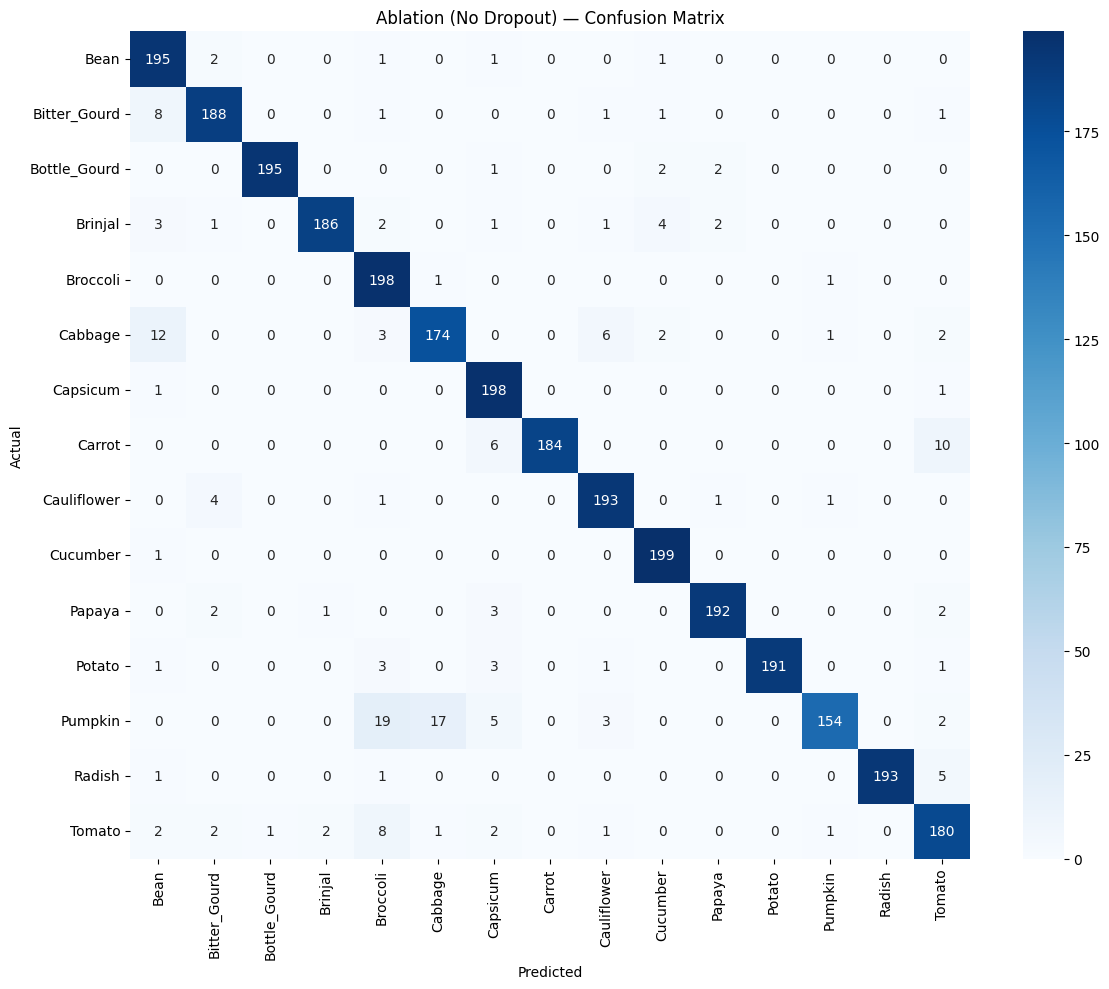

In [26]:
# Ablation Study — Remove Dropout from Deeper model
def build_deeper_no_dropout():
    model = keras.Sequential([
        layers.Conv2D(32,  (3,3), activation='relu', padding='same', input_shape=(64,64,3)),
        layers.Conv2D(32,  (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(64,  (3,3), activation='relu', padding='same'),
        layers.Conv2D(64,  (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ], name='Deeper_No_Dropout')
    return model

ablation_model = build_deeper_no_dropout()
ablation_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_ablation = ablation_model.fit(
    train_gen, epochs=EPOCHS, validation_data=val_gen,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)
ablation_acc = evaluate_model(ablation_model, test_gen, 'Ablation (No Dropout)')

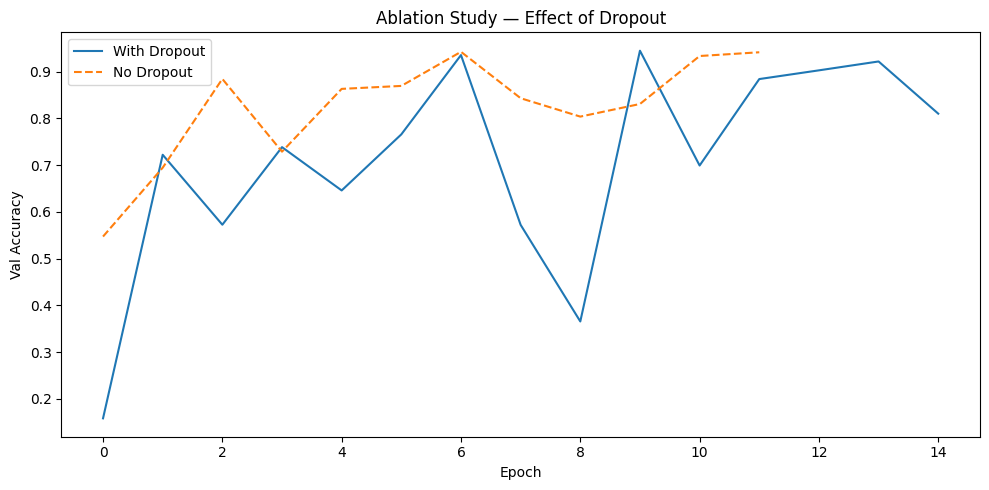

With Dropout Accuracy : 94.00%
No Dropout   Accuracy : 94.00%


In [27]:
# Ablation comparison plot
plt.figure(figsize=(10,5))
plt.plot(history_deeper.history['val_accuracy'],   label='With Dropout')
plt.plot(history_ablation.history['val_accuracy'], label='No Dropout',   linestyle='--')
plt.title('Ablation Study — Effect of Dropout')
plt.xlabel('Epoch'); plt.ylabel('Val Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

print(f'With Dropout Accuracy : {deeper_acc*100:.2f}%')
print(f'No Dropout   Accuracy : {ablation_acc*100:.2f}%')

---
# PART B — Transfer Learning with MobileNetV2
## Step 8 — Feature Extraction (Frozen Base)

In [28]:
# For Transfer Learning, use 224x224
TL_IMG_SIZE = (224, 224)

tl_train_datagen = ImageDataGenerator(
    rescale=1./255, rotation_range=20, zoom_range=0.2,
    horizontal_flip=True, width_shift_range=0.1, height_shift_range=0.1
)
tl_val_test_datagen = ImageDataGenerator(rescale=1./255)

tl_train_gen = tl_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=TL_IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical')
tl_val_gen = tl_val_test_datagen.flow_from_directory(
    VAL_DIR, target_size=TL_IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)
tl_test_gen = tl_val_test_datagen.flow_from_directory(
    TEST_DIR, target_size=TL_IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

Found 15000 images belonging to 15 classes.
Found 3000 images belonging to 15 classes.
Found 3000 images belonging to 15 classes.


In [31]:
# Load MobileNetV2 — freeze base
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False   # Feature extraction only

# Add custom head
inputs  = keras.Input(shape=(224, 224, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

tl_model = keras.Model(inputs, outputs, name='MobileNetV2_FeatureExtract')
tl_model.compile(optimizer=keras.optimizers.Adam(1e-3),
                 loss='categorical_crossentropy', metrics=['accuracy'])
tl_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_FeatureExtract"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,589,775 (9.88 MB)

 Trainable params: 331,791 (1.27 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [32]:
start = time.time()
history_tl = tl_model.fit(
    tl_train_gen, epochs=EPOCHS, validation_data=tl_val_gen,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
    ],
    verbose=1
)
tl_time = time.time() - start
print(f'\nTransfer Learning (Feature Extraction) time: {tl_time/60:.1f} minutes')

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 241s 471ms/step - accuracy: 0.9563 - loss: 0.1524 - val_accuracy: 0.9957 - val_loss: 0.0162 - learning_rate: 0.0010
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 202s 432ms/step - accuracy: 0.9875 - loss: 0.0429 - val_accuracy: 0.9940 - val_loss: 0.0167 - learning_rate: 0.0010
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 202s 430ms/step - accuracy: 0.9909 - loss: 0.0283 - val_accuracy: 0.9930 - val_loss: 0.0212 - learning_rate: 0.0010
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.9913 - loss: 0.0268
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
469/469 ━━━━━━━━━━━━━━━━━━━━ 199s 425ms/step - accuracy: 0.9925 - loss: 0.0240 - val_accuracy: 0.9923 - val_loss: 0.0216 - learning_rate: 0.0010
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 195s 415ms/step - accuracy: 0.9952 - loss: 0.0141 - val_accuracy: 0.9980 - val_loss: 0.0073 - learning_rate: 5.0000e-04
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 198s 422ms/step - accur

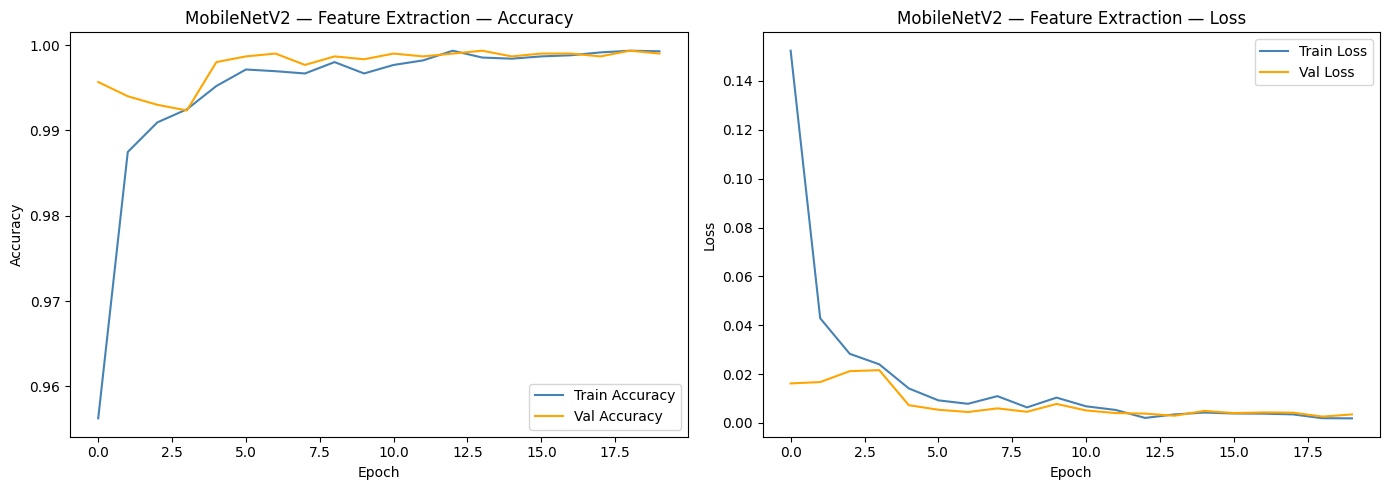


MobileNetV2 Feature Extraction — Test Loss: 0.0037 | Test Accuracy: 99.93%

Classification Report:
              precision    recall  f1-score   support

        Bean       1.00      1.00      1.00       200
Bitter_Gourd       1.00      0.99      1.00       200
Bottle_Gourd       1.00      1.00      1.00       200
     Brinjal       1.00      1.00      1.00       200
    Broccoli       1.00      1.00      1.00       200
     Cabbage       1.00      1.00      1.00       200
    Capsicum       1.00      1.00      1.00       200
      Carrot       1.00      1.00      1.00       200
 Cauliflower       1.00      1.00      1.00       200
    Cucumber       1.00      1.00      1.00       200
      Papaya       1.00      1.00      1.00       200
      Potato       1.00      1.00      1.00       200
     Pumpkin       1.00      0.99      1.00       200
      Radish       1.00      1.00      1.00       200
      Tomato       1.00      1.00      1.00       200

    accuracy                      

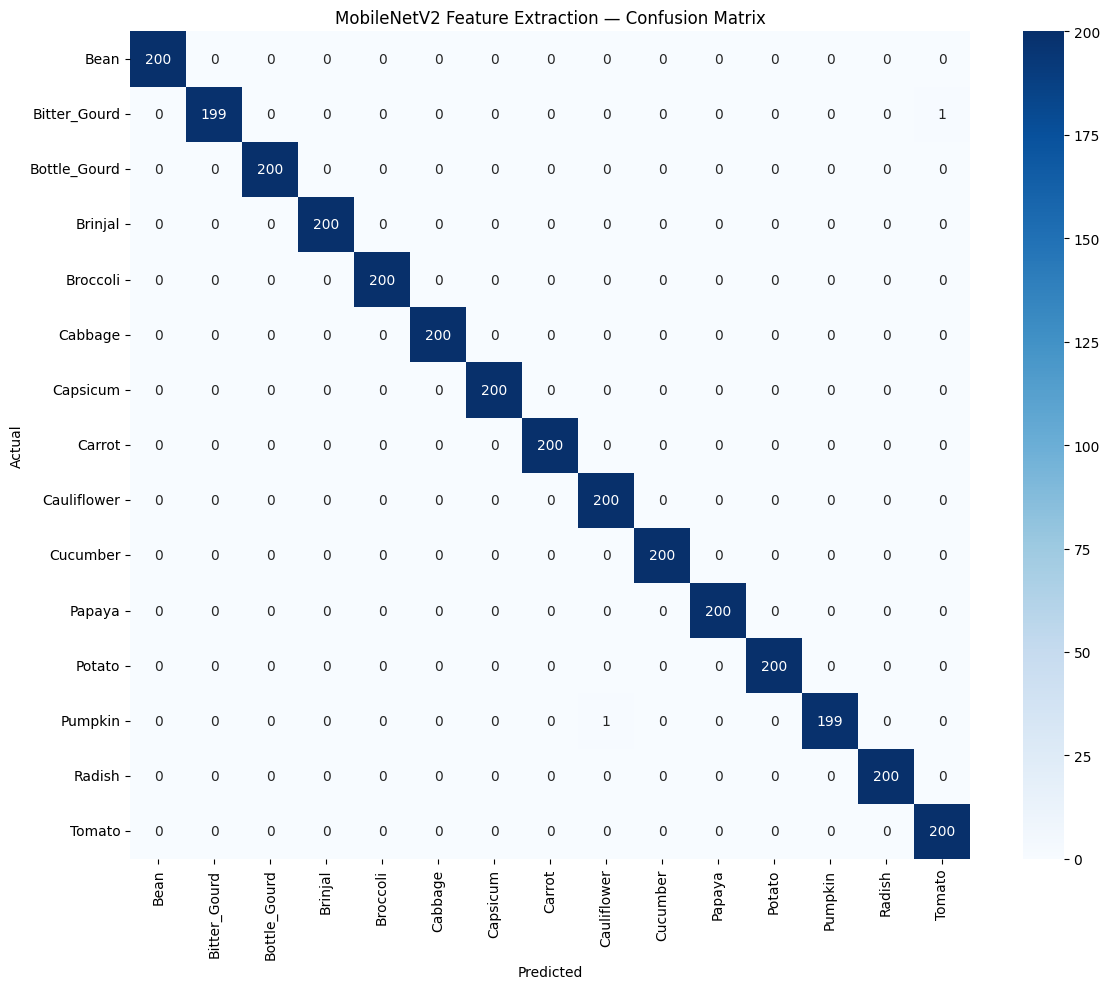

In [33]:
plot_history(history_tl, 'MobileNetV2 — Feature Extraction')
tl_acc = evaluate_model(tl_model, tl_test_gen, 'MobileNetV2 Feature Extraction')

## Step 9 — Fine-Tuning (Unfreeze Top Layers)

In [34]:
# Unfreeze the last 30 layers of the base model
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with lower learning rate
tl_model.compile(optimizer=keras.optimizers.Adam(1e-5),
                 loss='categorical_crossentropy', metrics=['accuracy'])

start = time.time()
history_ft = tl_model.fit(
    tl_train_gen, epochs=EPOCHS, validation_data=tl_val_gen,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
    ],
    verbose=1
)
ft_time = time.time() - start
print(f'\nFine-Tuning time: {ft_time/60:.1f} minutes')

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 230s 452ms/step - accuracy: 0.9692 - loss: 0.1045 - val_accuracy: 0.9993 - val_loss: 0.0066 - learning_rate: 1.0000e-05
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 195s 415ms/step - accuracy: 0.9892 - loss: 0.0348 - val_accuracy: 0.9993 - val_loss: 0.0043 - learning_rate: 1.0000e-05
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 193s 412ms/step - accuracy: 0.9914 - loss: 0.0264 - val_accuracy: 0.9987 - val_loss: 0.0048 - learning_rate: 1.0000e-05
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 192s 410ms/step - accuracy: 0.9942 - loss: 0.0176 - val_accuracy: 0.9987 - val_loss: 0.0045 - learning_rate: 1.0000e-05
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 190s 405ms/step - accuracy: 0.9945 - loss: 0.0156 - val_accuracy: 0.9993 - val_loss: 0.0036 - learning_rate: 1.0000e-05
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 192s 409ms/step - accuracy: 0.9953 - loss: 0.0131 - val_accuracy: 0.9990 - val_loss: 0.0037 - learning_rate: 1.0000e-05
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 

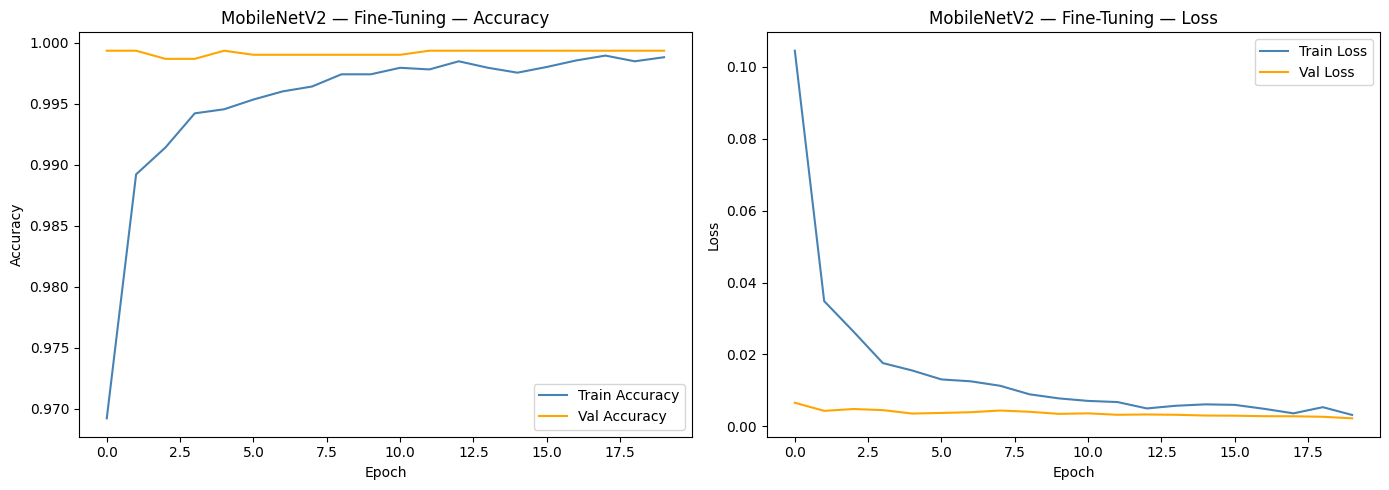


MobileNetV2 Fine-Tuned — Test Loss: 0.0025 | Test Accuracy: 99.93%

Classification Report:
              precision    recall  f1-score   support

        Bean       1.00      1.00      1.00       200
Bitter_Gourd       1.00      0.99      0.99       200
Bottle_Gourd       1.00      1.00      1.00       200
     Brinjal       1.00      1.00      1.00       200
    Broccoli       1.00      1.00      1.00       200
     Cabbage       1.00      1.00      1.00       200
    Capsicum       1.00      1.00      1.00       200
      Carrot       1.00      1.00      1.00       200
 Cauliflower       1.00      1.00      1.00       200
    Cucumber       1.00      1.00      1.00       200
      Papaya       1.00      1.00      1.00       200
      Potato       1.00      1.00      1.00       200
     Pumpkin       1.00      1.00      1.00       200
      Radish       1.00      1.00      1.00       200
      Tomato       1.00      1.00      1.00       200

    accuracy                           1.0

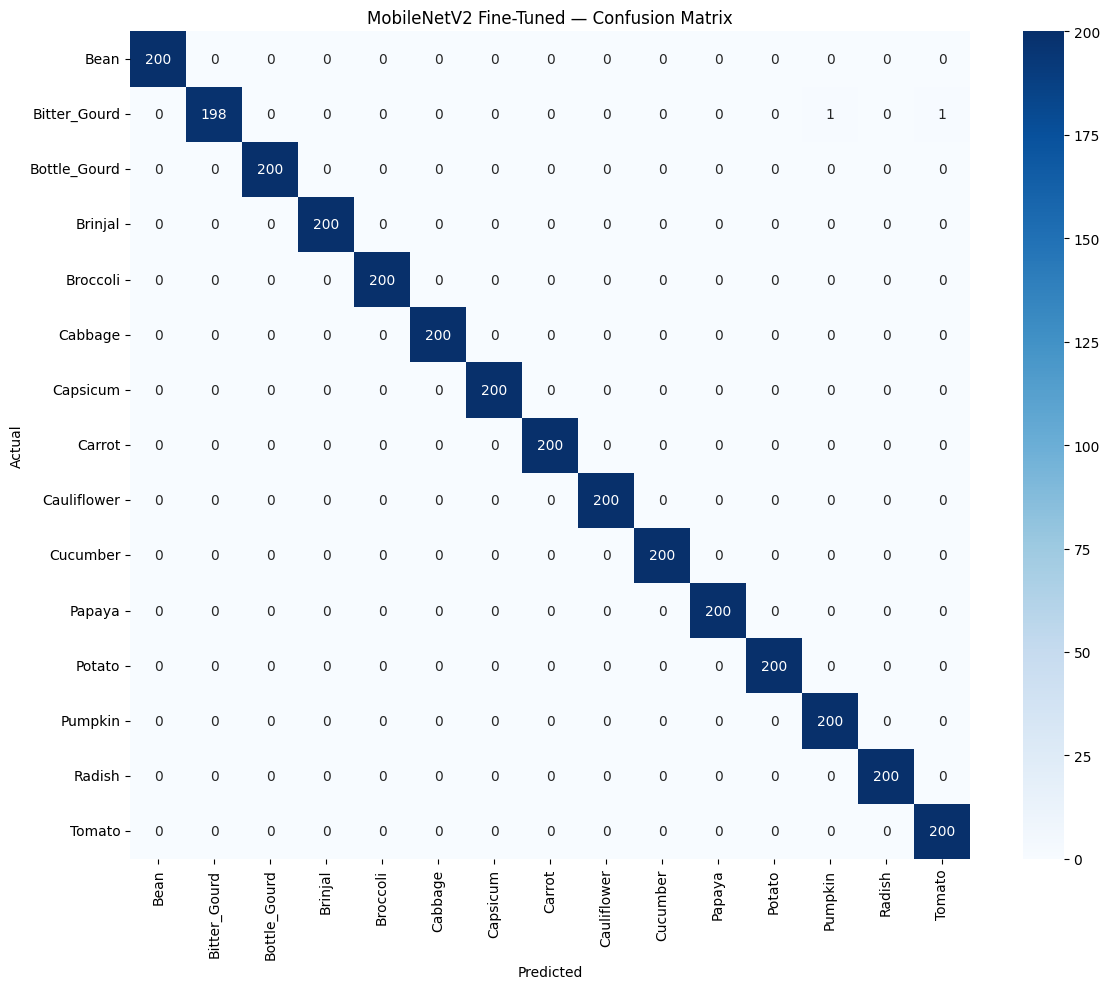

In [35]:
plot_history(history_ft, 'MobileNetV2 — Fine-Tuning')
ft_acc = evaluate_model(tl_model, tl_test_gen, 'MobileNetV2 Fine-Tuned')

## Step 10 — Final Summary: All Models Compared


Model                       Accuracy   Time (min)
Baseline CNN                  88.87%         12.8
Deeper CNN                    94.00%         10.4
Ablation (No Dropout)         94.00%         10.4
MobileNetV2 FE                99.93%         66.5
MobileNetV2 FT                99.93%         65.2


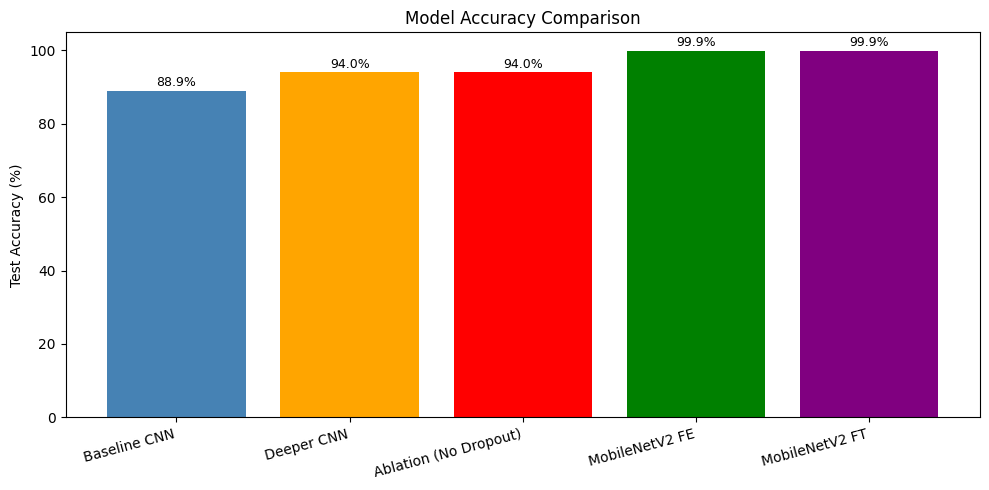

In [36]:
models_names = ['Baseline CNN', 'Deeper CNN', 'Ablation (No Dropout)', 'MobileNetV2 FE', 'MobileNetV2 FT']
accuracies   = [baseline_acc*100, deeper_acc*100, ablation_acc*100, tl_acc*100, ft_acc*100]
times_min    = [baseline_time/60, deeper_time/60, deeper_time/60, tl_time/60, ft_time/60]

print('\n' + '='*55)
print(f"{'Model':<25} {'Accuracy':>10} {'Time (min)':>12}")
print('='*55)
for n, a, t in zip(models_names, accuracies, times_min):
    print(f"{n:<25} {a:>9.2f}% {t:>12.1f}")
print('='*55)

# Bar chart
plt.figure(figsize=(10, 5))
bars = plt.bar(models_names, accuracies, color=['steelblue','orange','red','green','purple'])
plt.ylabel('Test Accuracy (%)')
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=15, ha='right')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()